# Notebook 2 Generating a Transient Population

In this notebook we generate a mixed population of supernovae (SN) and kilonovae (KN) 
within the synthetic universe constructed in Notebook 1.

We assume:

- Supernova rate ∝ Star Formation Rate (SFR)
- Kilonova rate ∝ Total Stellar Mass (M_star)
- Absolute magnitude M = -16 for both populations
- Survey duration T = 500 year

This notebook produces an intrinsic transient population and computes 
their apparent magnitudes using the distance modulus.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline


## Load Synthetic Galaxy Catalogue

We import the galaxy catalogue generated in Notebook 1.

This catalogue contains:

- Distance (Mpc)
- Stellar Mass (M_star)
- Star Formation Rate (SFR)
- Galaxy properties

In [2]:
galaxies = pd.read_csv("galaxy_catalog.csv")

print("Number of galaxies:", len(galaxies))
galaxies.head()


Number of galaxies: 50000


,x,y,z,distance,M_star,SFR,is_quiescent,L
0,-135.980529,-75.625049,-150.179101,216.248964,1.166272e+10,0.002688,True,0.009308
1,-290.744878,-49.749084,3.234814,294.988169,5.648145e+09,0.001249,True,0.001237
2,-127.169016,172.656237,164.673388,270.369118,5.612331e+09,0.007538,True,0.002440
3,-222.527760,9.495705,-119.665529,252.841079,5.976691e+09,0.001379,True,0.001037
4,-105.454176,119.467975,26.267419,161.502811,3.702149e+09,0.001622,True,0.001927


## Physical Event Rates

We assume simple host galaxy scaling relations.

The supernova rate in each galaxy is proportional to its star formation rate.

The kilonova rate in each galaxy is proportional to its stellar mass.

---

### Assumptions

- Core collapse supernovae trace ongoing star formation.
- Kilonovae trace stellar mass as a proxy for delayed mergers.
- Rates are constant over the survey duration.

Survey duration: 500 year.

---

### Normalizations

Supernova normalization: 0.01 events per year per solar mass per year of star formation.

Kilonova normalization: 1 × 10^-15 events per year per solar mass of stellar mass.

These values reproduce realistic order-of-magnitude local event rates.

In [3]:
A_SN = 1e-6       # SN per (Msun/yr) per year
A_KN = 1e-18      # KN per Msun per year
T_survey = 500000.0     # years

## Sampling Event Counts

For each galaxy, we compute the expected number of events over the survey duration.

The expected supernova count scales with star formation rate.

The expected kilonova count scales with stellar mass.

Actual event numbers are drawn from a Poisson distribution with these expected values as the mean.

The expected totals represent the ensemble average.

The realised totals represent one Monte Carlo survey realisation.

In [4]:
lambda_SN = A_SN * galaxies["SFR"] * T_survey
lambda_KN = A_KN * galaxies["M_star"] * T_survey

N_SN = np.random.poisson(lambda_SN)
N_KN = np.random.poisson(lambda_KN)

print("Total expected SN:", lambda_SN.sum())
print("Total expected KN:", lambda_KN.sum())

print("Total realised SN:", N_SN.sum())
print("Total realised KN:", N_KN.sum())

Total expected SN: 5046.184724113487
Total expected KN: 139.83174577575707
Total realised SN: 4928
Total realised KN: 131


## Construct Event Catalogue

We expand galaxy level event counts into an event-level table.

Each event stores:

- Event type (SN or KN)
- Host galaxy distance

This produces the intrinsic transient population.

In [5]:
events = []

for i in range(len(galaxies)):
    d = galaxies["distance"].iloc[i]

    for _ in range(N_SN[i]):
        events.append({"type": "SN", "distance": d})

    for _ in range(N_KN[i]):
        events.append({"type": "KN", "distance": d})

events = pd.DataFrame(events)

print("Total SN:", (events["type"] == "SN").sum())
print("Total KN:", (events["type"] == "KN").sum())
print("Total events:", len(events))


Total SN: 4928
Total KN: 131
Total events: 5059


## Convert to Apparent Magnitude

We assume a fixed absolute magnitude:

M = -16

The distance modulus is:

μ = 5 log10(d_Mpc) + 25

The apparent magnitude is:

m = M + μ



In [6]:
M_abs = -16

events["mu"] = 5 * np.log10(events["distance"]*1e6) - 5
events["m"] = M_abs + events["mu"]

events.head()

,type,distance,mu,m
0,SN,296.960290,37.363492,21.363492
1,SN,191.175168,36.407157,20.407157
2,SN,293.823607,37.340433,21.340433
3,SN,106.886151,35.144607,19.144607
4,SN,285.633320,37.279044,21.279044


### Brightness Range of Injected Events

This cell computes the apparent magnitude range of the simulated transient population.

- The minimum value of `m` corresponds to the brightest detected event.
- The maximum value of `m` corresponds to the faintest detected event.

This provides a quick validation that the injected supernovae and kilonovae span a physically reasonable magnitude range within the survey limits.


In [7]:
print("Brightest event:", events["m"].min())
print("Faintest event:", events["m"].max())

Brightest event: 14.934514674384864
Faintest event: 21.384990447609646


### Apparent Magnitude as a Function of Distance

This cell compares the simulated events to the theoretical distance–magnitude relation.

- A smooth distance grid `d` is created between the minimum and maximum event distances.


  where an absolute magnitude of M = -16 is assumed.
- The simulated event magnitudes are plotted as scatter points.
- The theoretical curve is overlaid for comparison.
- The y-axis is inverted because lower magnitudes correspond to brighter objects.

This verifies that the injected events follow the expected luminosity–distance scaling.


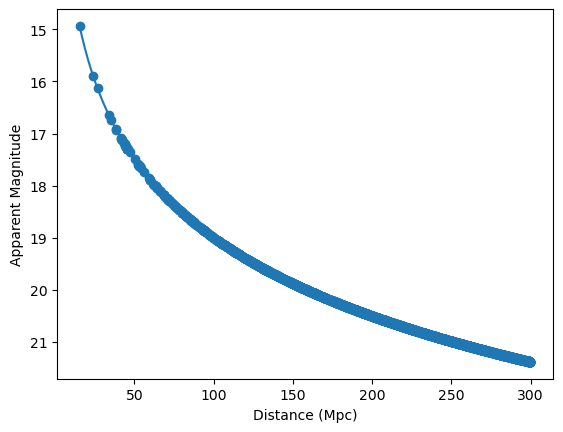

In [8]:

d = np.linspace(events["distance"].min(), 
                events["distance"].max(), 500)

m_model = -16 + 5*np.log10(d*1e6) - 5

plt.figure()
plt.scatter(events["distance"], events["m"])
plt.plot(d, m_model)

plt.xlabel("Distance (Mpc)")
plt.ylabel("Apparent Magnitude")
plt.gca().invert_yaxis()
plt.show()

### Apparent Magnitude Distribution: Supernovae vs Kilonovae

This cell compares the apparent magnitude distributions of Supernovae (SN) and Kilonovae (KN).

- The events are separated by type (`SN` and `KN`).
- Histograms of their apparent magnitudes (`m`) are plotted.
- A logarithmic y-axis is used to clearly show differences in event counts.
- This highlights the relative abundance of SN compared to the much rarer KN population.

The plot allows a direct visual comparison of brightness distributions and population imbalance between the two transient types.


[]

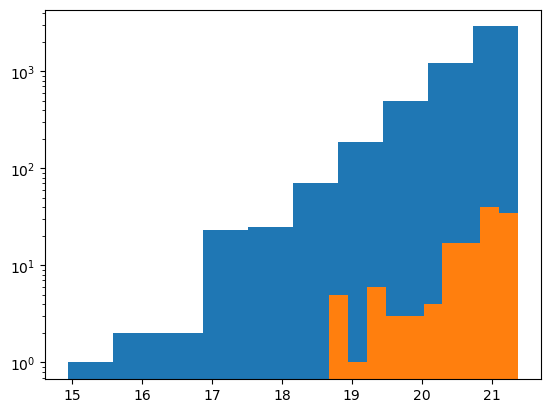

In [9]:
plt.hist(events[events['type']=='SN']['m'], label='SN')
plt.hist(events[events['type']=='KN']['m'], label='KN')

plt.semilogy()

### Inspecting Kilonova Events in the Synthetic Sample

This cell filters the event catalogue to show only Kilonova (KN) events.


In [10]:
events[events['type']=='KN']


,type,distance,mu,m
66,KN,197.447304,36.477256,20.477256
119,KN,264.235247,37.109954,21.109954
133,KN,241.208583,36.911964,20.911964
240,KN,298.798793,37.376894,21.376894
257,KN,193.993222,36.438933,20.438933
...,...,...,...,...
4930,KN,244.002433,36.936971,20.936971
4955,KN,251.132458,36.999514,20.999514
4981,KN,253.039634,37.015943,21.015943
5004,KN,220.570104,36.717733,20.717733


## SN 1993J r-band Light Curve

This cell plots the observed r-band light curve of the Type IIb supernova SN 1993J.

- The x-axis shows time in days since explosion.
- The y-axis shows apparent R-band magnitude.
- The y-axis is inverted because smaller magnitudes are brighter.
- Each point is a real observational measurement.

This allows direct visual comparison with AT2017gfo.

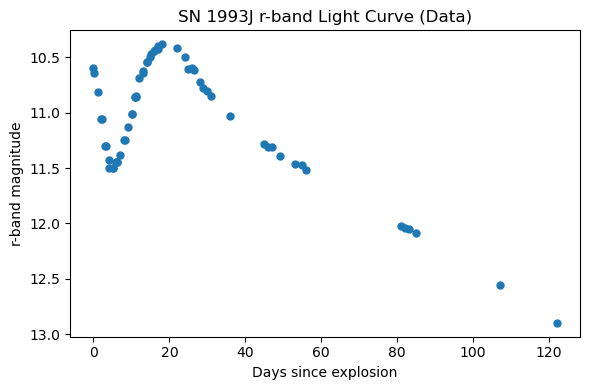

In [11]:
df_93 = pd.read_csv(os.path.expanduser("~/Downloads/sn1993j_rband_shifted.csv"))

plt.figure(figsize=(6,4))
plt.scatter(df_93["t_days"], df_93["R_app"], s=25)

plt.gca().invert_yaxis()
plt.xlabel("Days since explosion")
plt.ylabel("r-band magnitude")
plt.title("SN 1993J r-band Light Curve (Data)")
plt.tight_layout()
plt.show()


### Loading the AT2017gfo r-band Kilonova Data

This cell loads the real photometric data for the kilonova AT2017gfo.

- The file contains multi-band observations compiled from the literature.
- Each row corresponds to a measurement at a given time since merger (`Phase`).
- The `mag` column contains the observed apparent magnitude.
- The `Band` column specifies the filter (we will later isolate r-band only).

This dataset provides a fully data-driven kilonova light curve for direct comparison with the Type IIb supernova.


In [12]:
df_kn = pd.read_csv(os.path.expanduser("~/Downloads/at2017gfo_rband.csv"))
df_kn = df_kn[df_kn["Band"] == "r"].copy()
df_kn_r = df_kn   # alias used in later cells

print("Number of r-band points:", len(df_kn))

# Upper-limit mask: suspicious late-time points — define once, reuse everywhere
mask_kn = ((df_kn_r["Phase"] > 8) & (df_kn_r["mag"] < 20.5)) | (df_kn_r["Phase"] > 16)
kn_det = df_kn_r[~mask_kn]
kn_lim = df_kn_r[mask_kn]

df_kn.head()


Number of r-band points: 101


,MJD,Phase,Inst,Tel,Band,l_mag,mag,e_mag,Delta,Ref,Use,Avg,Rt,Out,Exc
2,57982.993,0.464,AltaU47+,Prompt5,r,NaN,17.46,0.03,0.00,2017ApJ...848L..24V,*,NaN,NaN,NaN,NaN
6,57983.000,0.471,LDSS,Magellan,r,NaN,17.33,0.02,0.00,2017arXiv171005443D,*,NaN,NaN,NaN,NaN
18,57983.028,0.499,AltaU47+,Prompt5,r,NaN,17.56,0.04,0.00,2017ApJ...848L..24V,*,NaN,NaN,NaN,NaN
24,57983.050,0.521,ROS2,REM,r,NaN,17.14,0.08,0.00,2017Natur.551...67P,*,NaN,NaN,NaN,NaN
38,57983.405,0.876,Sinistro,LCO1m,r,NaN,17.20,0.02,-0.02,2017Natur.551...64A,*,NaN,NaN,NaN,NaN


### Selecting Only r-band Kilonova Data

This cell filters the full AT2017gfo dataset to keep only r-band measurements.

- The original table contains multiple photometric bands.
- We restrict to rows where `Band == "r"`.
- A copy of the filtered dataframe is created to avoid modifying the original data.

This ensures we are comparing SN 2011dh and AT2017gfo in the same photometric band.


### AT2017gfo r-band Light Curve


We apply a physical sanity filter:

- Use r-band only  
- Respect published upper limits  
- After 8 days, any point brighter than 20.5 mag is treated as an upper limit  

This prevents artificial late-time rebrightening.


## Apparent r-band Light Curves

This cell plots the observed r-band light curves of SN 1993J and AT2017gfo.

- The x-axis shows time in days since explosion (SN 1993J) or merger (AT2017gfo).
- The y-axis shows apparent r-band magnitude.
- The y-axis is inverted because smaller magnitudes are brighter.
- Each point represents a real observational measurement.

This allows direct visual comparison between a Type IIb supernova and a kilonova in the same photometric band.

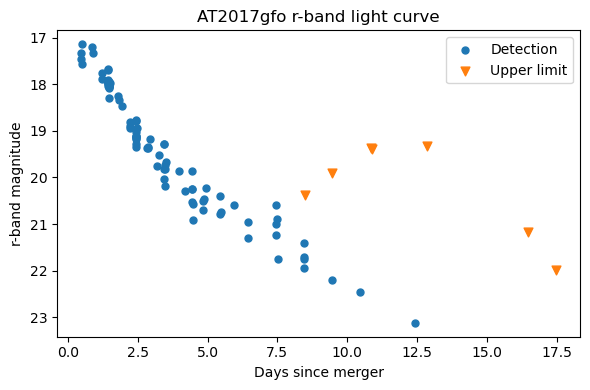

In [13]:
detections   = kn_det
upper_limits = kn_lim

plt.figure(figsize=(6,4))
plt.scatter(detections["Phase"], detections["mag"], s=25, label="Detection")
plt.scatter(upper_limits["Phase"], upper_limits["mag"], marker="v", s=40, label="Upper limit")

plt.gca().invert_yaxis()
plt.xlabel("Days since merger")
plt.ylabel("r-band magnitude")
plt.title("AT2017gfo r-band light curve")
plt.legend()
plt.tight_layout()
plt.show()


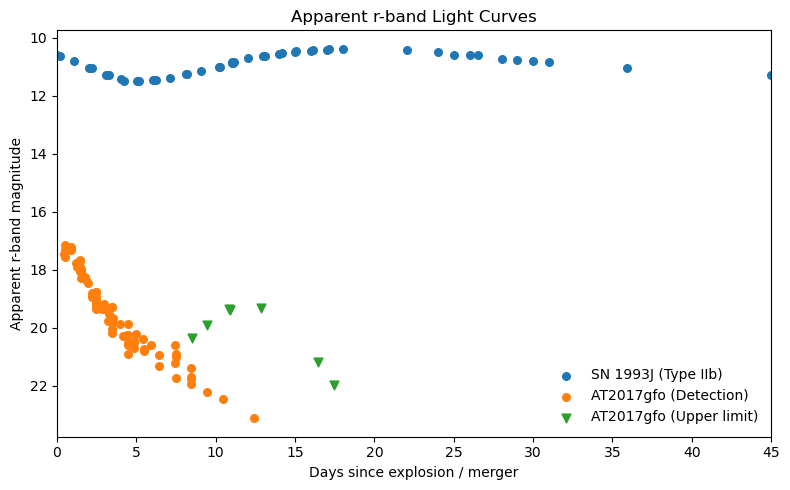

In [14]:
phase_sn = df_93["t_days"]
r_sn = df_93["R_app"]

phase_kn_det = kn_det["Phase"]
r_kn_det = kn_det["mag"]
phase_kn_lim = kn_lim["Phase"]
r_kn_lim = kn_lim["mag"]

plt.figure(figsize=(8,5))
plt.scatter(phase_sn, r_sn, s=30, label="SN 1993J (Type IIb)")
plt.scatter(phase_kn_det, r_kn_det, s=30, label="AT2017gfo (Detection)")
plt.scatter(phase_kn_lim, r_kn_lim, marker="v", s=40, label="AT2017gfo (Upper limit)")

plt.xlabel("Days since explosion / merger")
plt.ylabel("Apparent r-band magnitude")
plt.title("Apparent r-band Light Curves")
plt.gca().invert_yaxis()
plt.xlim(0, 45)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## Absolute r-band Light Curves

This cell converts both light curves to absolute magnitude.

- The distance modulus is computed using:
  μ = 5 log10(d_Mpc × 10^6) − 5
- SN 1993J is assumed to be at 3.6 Mpc.
- AT2017gfo is assumed to be at 40 Mpc.
- Absolute magnitude is computed as:
  M = m − μ

This allows direct physical comparison of intrinsic brightness.

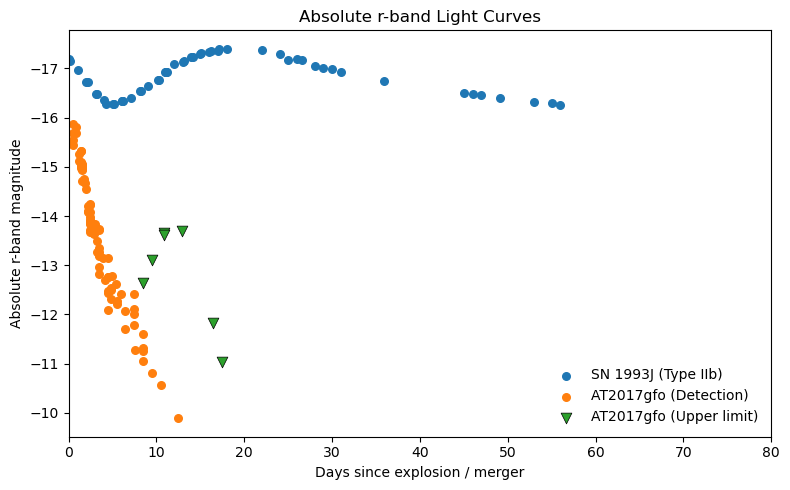

In [15]:
d_93 = 3.6    # Mpc
d_kn = 40.0   # Mpc

mu_93 = 5 * np.log10(d_93 * 1e6) - 5
mu_kn = 5 * np.log10(d_kn * 1e6) - 5

M_93      = r_sn - mu_93
M_kn_det  = r_kn_det - mu_kn
M_kn_lim  = r_kn_lim - mu_kn

plt.figure(figsize=(8,5))
plt.scatter(phase_sn, M_93, s=30, label="SN 1993J (Type IIb)")
plt.scatter(phase_kn_det, M_kn_det, s=30, label="AT2017gfo (Detection)")
plt.scatter(phase_kn_lim, M_kn_lim, marker="v", s=60, edgecolor="black", linewidth=0.5, label="AT2017gfo (Upper limit)")

plt.xlabel("Days since explosion / merger")
plt.ylabel("Absolute r-band magnitude")
plt.title("Absolute r-band Light Curves")
plt.gca().invert_yaxis()
plt.xlim(0, 80)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


SN: no error column found — using sigma = 0.1 mag
KN: using per-point errors from column 'e_mag'


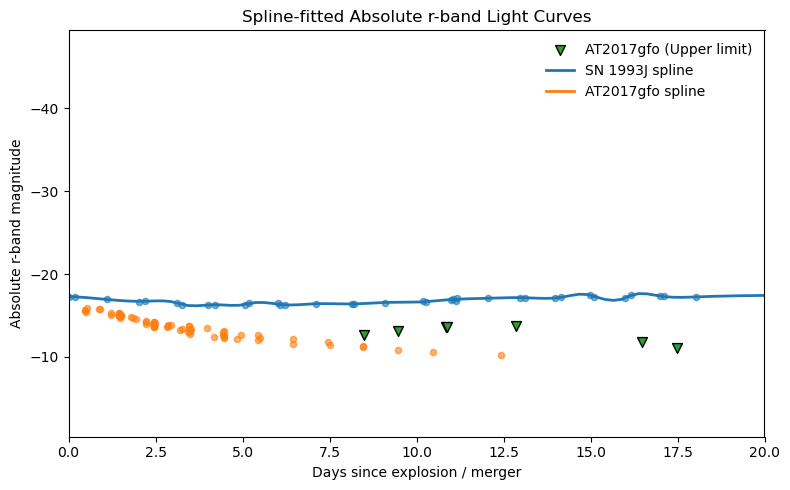

SN template shifted by +31.20 mag  (raw peak was -47.20)
KN template shifted by +nan mag  (raw peak was nan)


In [16]:
# Sort data before fitting splines
idx_sn = np.argsort(phase_sn)
phase_sn_sorted = phase_sn.values[idx_sn]
M_sn_sorted = M_93.values[idx_sn]

idx_kn = np.argsort(phase_kn_det)
phase_kn_sorted = phase_kn_det.values[idx_kn]
M_kn_sorted = M_kn_det.values[idx_kn]

# --- Monte Carlo resampling ---
# Nudge each sorted data point by its photometric uncertainty before fitting.
# Use per-point error columns from the source CSVs if available;
# fall back to a fixed sigma = 0.1 mag otherwise.
_err_cols = ["magerr", "e_mag", "mag_err", "sigma", "err"]

_sn_err_col = next((c for c in _err_cols if c in df_93.columns), None)
sigma_sn = df_93[_sn_err_col].values[idx_sn] if _sn_err_col else 0.1
if _sn_err_col:
    print(f"SN: using per-point errors from column '{_sn_err_col}'")
else:
    print("SN: no error column found — using sigma = 0.1 mag")

_kn_err_col = next((c for c in _err_cols if c in kn_det.columns), None)
sigma_kn = kn_det[_kn_err_col].values[idx_kn] if _kn_err_col else 0.1
if _kn_err_col:
    print(f"KN: using per-point errors from column '{_kn_err_col}'")
else:
    print("KN: no error column found — using sigma = 0.1 mag")

M_sn_resampled = M_sn_sorted + np.random.normal(0, sigma_sn, size=M_sn_sorted.shape)
M_kn_resampled = M_kn_sorted + np.random.normal(0, sigma_kn, size=M_kn_sorted.shape)

# Fit splines to resampled data
spline_sn = UnivariateSpline(phase_sn_sorted, M_sn_resampled, s=0.15)
spline_kn = UnivariateSpline(phase_kn_sorted, M_kn_resampled, s=3.9)

# Evaluation grids
t_sn = np.linspace(phase_sn_sorted.min(), phase_sn_sorted.max(), 500)
t_kn = np.linspace(phase_kn_sorted.min(), phase_kn_sorted.max(), 500)

M_sn_smooth = spline_sn(t_sn)
M_kn_smooth = spline_kn(t_kn)

# Plot (scatter shows resampled points — i.e. what the spline was fitted to)
plt.figure(figsize=(8,5))
plt.scatter(phase_sn_sorted, M_sn_resampled, s=20, alpha=0.6)
plt.scatter(phase_kn_sorted, M_kn_resampled, s=20, alpha=0.6)
plt.scatter(phase_kn_lim, M_kn_lim, marker="v", s=50, edgecolor="black", label="AT2017gfo (Upper limit)")
plt.plot(t_sn, M_sn_smooth, linewidth=2, label="SN 1993J spline")
plt.plot(t_kn, M_kn_smooth, linewidth=2, label="AT2017gfo spline")
plt.xlim(0, 20)
plt.gca().invert_yaxis()
plt.xlabel("Days since explosion / merger")
plt.ylabel("Absolute r-band magnitude")
plt.title("Spline-fitted Absolute r-band Light Curves")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# --- Normalise both templates to the same peak absolute magnitude ---
# Ensures brightness cannot discriminate KN from SN; only fade rate can.
M_peak = -16.0

sn_offset = M_peak - M_sn_smooth.min()
kn_offset = M_peak - M_kn_smooth.min()

_spline_sn_raw = spline_sn
_spline_kn_raw = spline_kn
spline_sn = lambda t: _spline_sn_raw(t) + sn_offset
spline_kn = lambda t: _spline_kn_raw(t) + kn_offset

print(f"SN template shifted by {sn_offset:+.2f} mag  (raw peak was {M_sn_smooth.min():.2f})")
print(f"KN template shifted by {kn_offset:+.2f} mag  (raw peak was {M_kn_smooth.min():.2f})")

### 72 Hour Survey Configuration

We simulate a 72 hour transient survey with daily cadence.

Observation epochs are defined at:
t = 0, 1, 2 days.

This represents the minimal time baseline required to test early light curve evolution differences between kilonovae and supernovae.

In [17]:
np.random.seed(67)

# 72 hour survey: 4 epochs at daily cadence
t_obs = np.array([0, 1, 2, 3])  # days

# LSST single-visit r-band limiting magnitude
m_lim = 24.5


def sample_distance(d_min=50, d_max=600):
    """Draw a distance uniformly in volume (proportional to d^2 dd)."""
    u = np.random.uniform()
    return (d_min**3 + u * (d_max**3 - d_min**3)) ** (1 / 3)


### Observed Light Curve Model

For each injected event, the following steps are applied:

1. Evaluate the absolute magnitude template spline at rest-frame time.
2. Remove pre-explosion epochs (t < 0).
3. Convert to apparent magnitude using the distance modulus:
   μ = 5 log10(d_Mpc × 10^6) − 5
4. Apply magnitude-dependent photometric uncertainty:
   σ = 0.1 mag at 20 mag,
   σ = 0.2 mag at 21 mag,
   linear interpolation between.

Gaussian noise is added to produce observed magnitudes.

In [18]:
def generate_observed_lightcurve(event_type, t0, d_mpc):

    # Rest-frame time
    t_rest = t_obs - t0

    # Evaluate absolute magnitude template
    if event_type == "SN":
        M = spline_sn(t_rest)
    else:
        M = spline_kn(t_rest)

    # Remove pre-explosion epochs
    M = np.array(M)
    M[t_rest < 0] = np.nan

    # Convert to apparent magnitude
    mu = 5 * np.log10(d_mpc * 1e6) - 5
    m_true = M + mu

    # Magnitude-dependent photometric uncertainty (linear 0.1→0.2 over 20–21 mag)
    sigma = np.where(m_true <= 20, 0.1, np.where(m_true >= 21, 0.2, 0.1 + 0.1 * (m_true - 20)))

    # Add Gaussian noise
    m_obs = m_true + np.random.normal(0, sigma)

    return m_obs, sigma


### Injection of 1 Kilonova and 15 Supernovae

We inject:
- 1 kilonova
- 15 Type IIb supernovae

Distances are drawn uniformly between 50 and 600 Mpc.

Explosion times are drawn uniformly between −1 and 0 days,
allowing events to be partially evolved at first detection.

This configuration approximates the expected contamination level in a 1000 deg² survey over 72 hours.

In [19]:
# --- Kilonova ---
kn_distance = sample_distance()
kn_t0 = np.random.uniform(-1, 0)
kn_lc, kn_sigma = generate_observed_lightcurve("KN", kn_t0, kn_distance)
kn_lc[kn_lc > m_lim] = np.nan   # epochs below limiting magnitude → non-detection

print(f"KN: d = {kn_distance:.1f} Mpc,  detected epochs = {np.sum(~np.isnan(kn_lc))} / {len(t_obs)}")

# --- Supernovae ---
sn_lcs = []
sn_sigmas = []

for _ in range(15):
    d = sample_distance()
    t0 = np.random.uniform(-1, 0)
    m_obs, sig = generate_observed_lightcurve("SN", t0, d)
    m_obs[m_obs > m_lim] = np.nan   # apply limiting magnitude
    sn_lcs.append(m_obs)
    sn_sigmas.append(sig)


KN: d = 490.4 Mpc,  detected epochs = 0 / 4


### 72-Hour Light Curve Comparison

Observed light curves are plotted over the four survey epochs.

Supernovae are shown in grey.
The kilonova is shown in red.

Over a 3 day baseline:
- Supernovae exhibit minimal magnitude evolution.
- Kilonovae exhibit rapid fading.

Separation between populations is therefore driven primarily by the measured light curve slope.

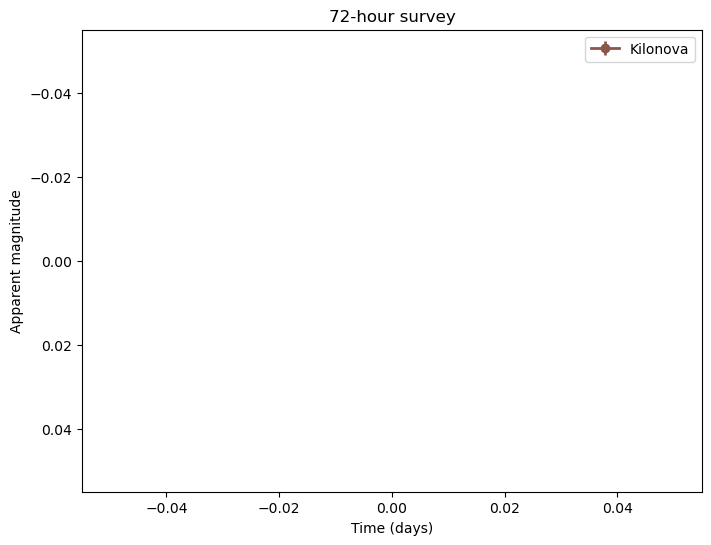

In [20]:
plt.figure(figsize=(8,6))

# Supernovae
for lc, sig in zip(sn_lcs, sn_sigmas):
    plt.errorbar(t_obs, lc, yerr=sig, fmt='o-', alpha=0.4)

# Kilonova
plt.errorbar(t_obs, kn_lc, yerr=kn_sigma, fmt='o-', linewidth=2, label="Kilonova")

plt.gca().invert_yaxis()
plt.xlabel("Time (days)")
plt.ylabel("Apparent magnitude")
plt.title("72-hour survey")
plt.legend()
plt.show()

KN fade rate : nan mag/day  →  SN ✗ (missed)
SN fade rates: []
SN false positives (misclassified as KN): 0 / 0


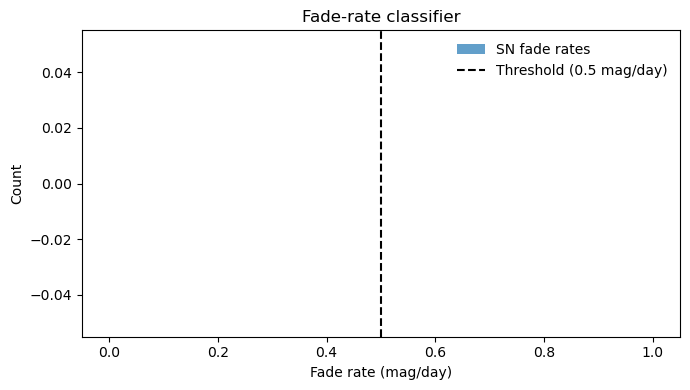

In [21]:
# --- Fade-rate classifier ---
# Kilonovae fade > ~0.5 mag/day in r-band; SNe barely evolve over 3 days.
KN_FADE_THRESHOLD = 0.5  # mag/day


def fade_rate(m_obs):
    """Linear fade rate (mag/day) over detected epochs. Returns NaN if < 2 detections."""
    valid = ~np.isnan(m_obs)
    if valid.sum() < 2:
        return np.nan
    t_valid = t_obs[valid]
    m_valid = m_obs[valid]
    # Positive = fading (getting fainter)
    return (m_valid[-1] - m_valid[0]) / (t_valid[-1] - t_valid[0])


kn_rate = fade_rate(kn_lc)
sn_rates = np.array([fade_rate(lc) for lc in sn_lcs])

# Classify
kn_label = "KN ✓" if (not np.isnan(kn_rate) and kn_rate > KN_FADE_THRESHOLD) else "SN ✗ (missed)"
sn_fp = np.sum(sn_rates[~np.isnan(sn_rates)] > KN_FADE_THRESHOLD)
sn_valid = np.sum(~np.isnan(sn_rates))

print(f"KN fade rate : {kn_rate:.3f} mag/day  →  {kn_label}")
print(f"SN fade rates: {[f'{r:.3f}' for r in sn_rates if not np.isnan(r)]}")
print(f"SN false positives (misclassified as KN): {sn_fp} / {sn_valid}")

# Plot fade-rate distributions
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sn_rates[~np.isnan(sn_rates)], bins=10, label="SN fade rates", alpha=0.7)
if not np.isnan(kn_rate):
    ax.axvline(kn_rate, color="red", linewidth=2, label=f"KN fade rate ({kn_rate:.2f} mag/day)")
ax.axvline(KN_FADE_THRESHOLD, color="black", linestyle="--", label=f"Threshold ({KN_FADE_THRESHOLD} mag/day)")
ax.set_xlabel("Fade rate (mag/day)")
ax.set_ylabel("Count")
ax.set_title("Fade-rate classifier")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
